# 🛒 EDA on Retail Sales Data
### Oasis Infobyte Internship — Data Analytics | Level 1, Task 1
**Name:** Param Parag Koli
**Batch:** July 2026

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 5)

print("✅ Libraries imported successfully!")

✅ Libraries imported successfully!


## 📂 Step 1 — Load Dataset & Initial Inspection

In [2]:
df = pd.read_csv('/content/retail_sales_dataset.csv')

print("Shape:", df.shape)
print("\nColumn Names:\n", df.columns.tolist())
print("\nData Types:\n", df.dtypes)
print("\nNull Values:\n", df.isnull().sum())
df.head(10)

Shape: (1000, 9)

Column Names:
 ['Transaction ID', 'Date', 'Customer ID', 'Gender', 'Age', 'Product Category', 'Quantity', 'Price per Unit', 'Total Amount']

Data Types:
 Transaction ID       int64
Date                object
Customer ID         object
Gender              object
Age                  int64
Product Category    object
Quantity             int64
Price per Unit       int64
Total Amount         int64
dtype: object

Null Values:
 Transaction ID      0
Date                0
Customer ID         0
Gender              0
Age                 0
Product Category    0
Quantity            0
Price per Unit      0
Total Amount        0
dtype: int64


,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount
0,1,2023-11-24,CUST001,Male,34,Beauty,3,50,150
1,2,2023-02-27,CUST002,Female,26,Clothing,2,500,1000
2,3,2023-01-13,CUST003,Male,50,Electronics,1,30,30
3,4,2023-05-21,CUST004,Male,37,Clothing,1,500,500
4,5,2023-05-06,CUST005,Male,30,Beauty,2,50,100
5,6,2023-04-25,CUST006,Female,45,Beauty,1,30,30
6,7,2023-03-13,CUST007,Male,46,Clothing,2,25,50
7,8,2023-02-22,CUST008,Male,30,Electronics,4,25,100
8,9,2023-12-13,CUST009,Male,63,Electronics,2,300,600
9,10,2023-10-07,CUST010,Female,52,Clothing,4,50,200


## 📊 Step 2 — Descriptive Statistics

In [3]:
print("Descriptive Statistics:\n")
print(df.describe())

print("\nMode:\n")
print(df.mode().iloc[0])

Descriptive Statistics:

       Transaction ID         Age     Quantity  Price per Unit  Total Amount
count     1000.000000  1000.00000  1000.000000     1000.000000   1000.000000
mean       500.500000    41.39200     2.514000      179.890000    456.000000
std        288.819436    13.68143     1.132734      189.681356    559.997632
min          1.000000    18.00000     1.000000       25.000000     25.000000
25%        250.750000    29.00000     1.000000       30.000000     60.000000
50%        500.500000    42.00000     3.000000       50.000000    135.000000
75%        750.250000    53.00000     4.000000      300.000000    900.000000
max       1000.000000    64.00000     4.000000      500.000000   2000.000000

Mode:

Transaction ID               1
Date                2023-05-16
Customer ID            CUST001
Gender                  Female
Age                       43.0
Product Category      Clothing
Quantity                   4.0
Price per Unit            50.0
Total Amount              

## 📈 Step 3 — Time Series Analysis (Monthly & Quarterly Sales)


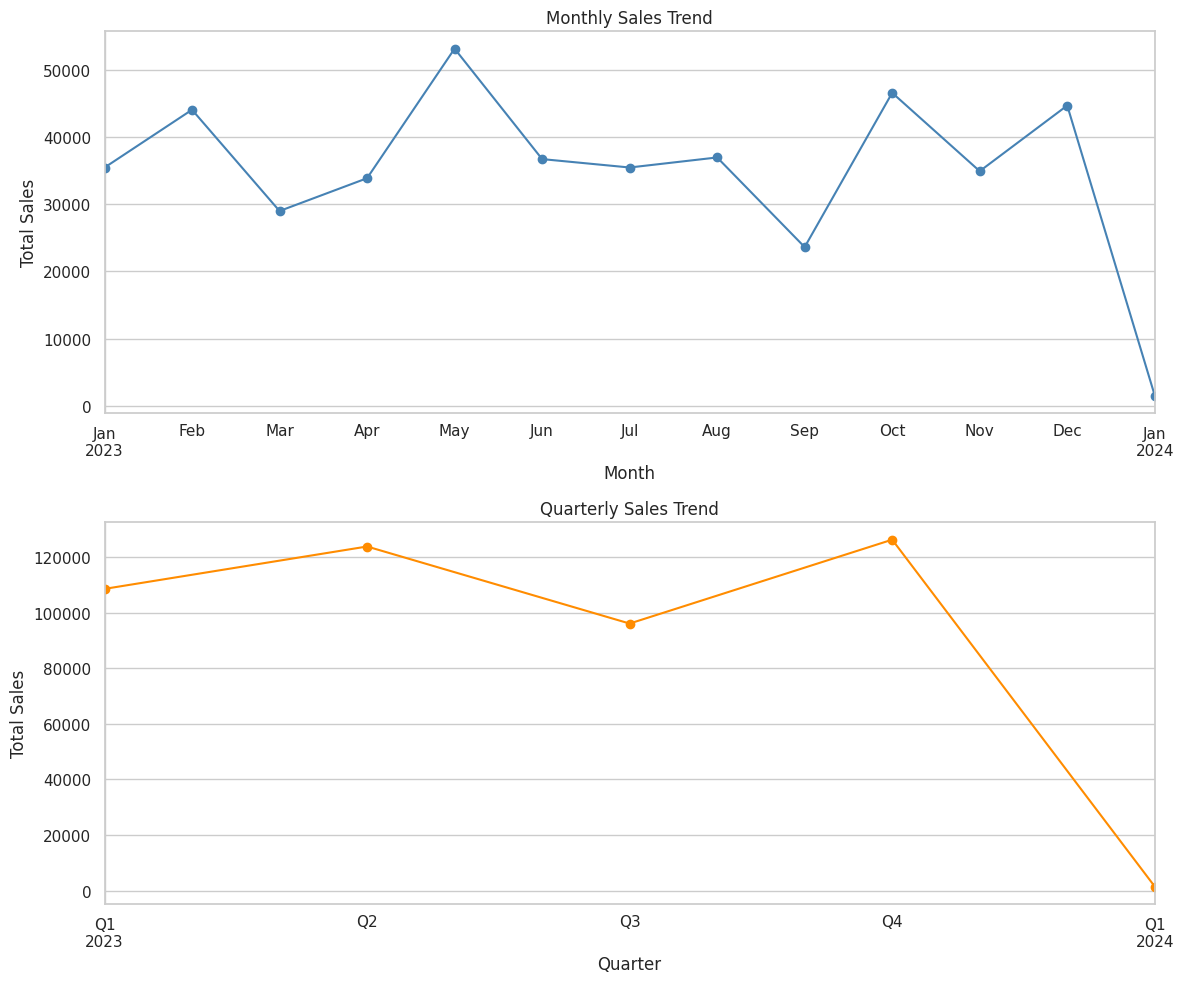

In [4]:
df['Date'] = pd.to_datetime(df['Date'])
df['Month'] = df['Date'].dt.to_period('M')
df['Quarter'] = df['Date'].dt.to_period('Q')

monthly_sales = df.groupby('Month')['Total Amount'].sum()
quarterly_sales = df.groupby('Quarter')['Total Amount'].sum()

fig, axes = plt.subplots(2, 1, figsize=(12, 10))

monthly_sales.plot(ax=axes[0], color='steelblue', marker='o')
axes[0].set_title('Monthly Sales Trend')
axes[0].set_xlabel('Month')
axes[0].set_ylabel('Total Sales')

quarterly_sales.plot(ax=axes[1], color='darkorange', marker='o')
axes[1].set_title('Quarterly Sales Trend')
axes[1].set_xlabel('Quarter')
axes[1].set_ylabel('Total Sales')

plt.tight_layout()
plt.show()

## 👥 Step 4 — Customer Demographics Analysis


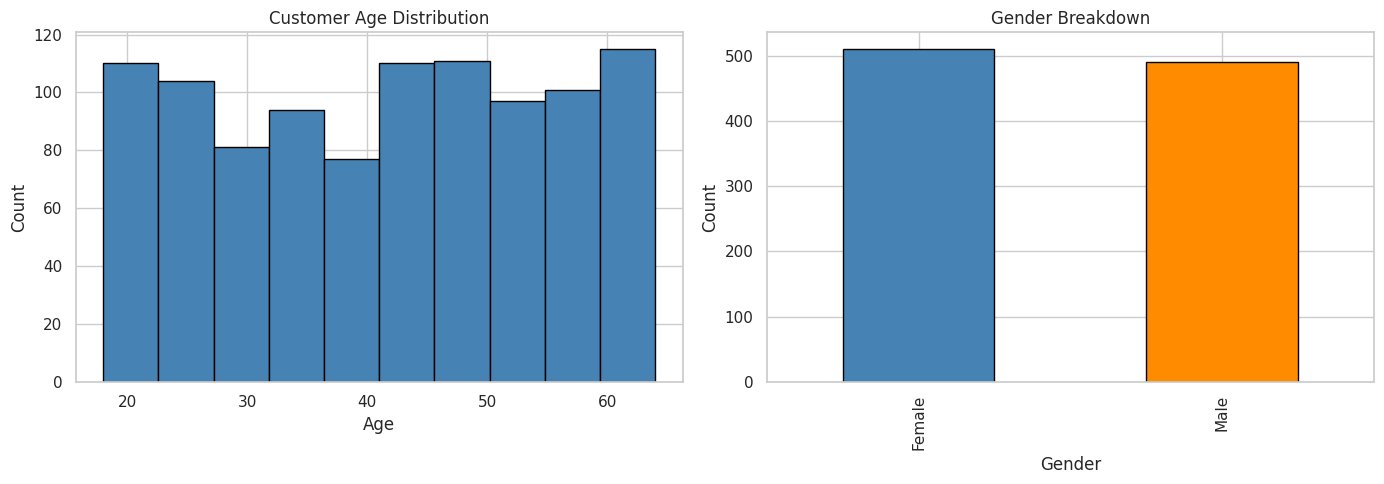

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

df['Age'].plot(kind='hist', bins=10, ax=axes[0], color='steelblue', edgecolor='black')
axes[0].set_title('Customer Age Distribution')
axes[0].set_xlabel('Age')
axes[0].set_ylabel('Count')

df['Gender'].value_counts().plot(kind='bar', ax=axes[1], color=['steelblue', 'darkorange'], edgecolor='black')
axes[1].set_title('Gender Breakdown')
axes[1].set_xlabel('Gender')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.show()

## 🛍️ Step 5 — Product Analysis


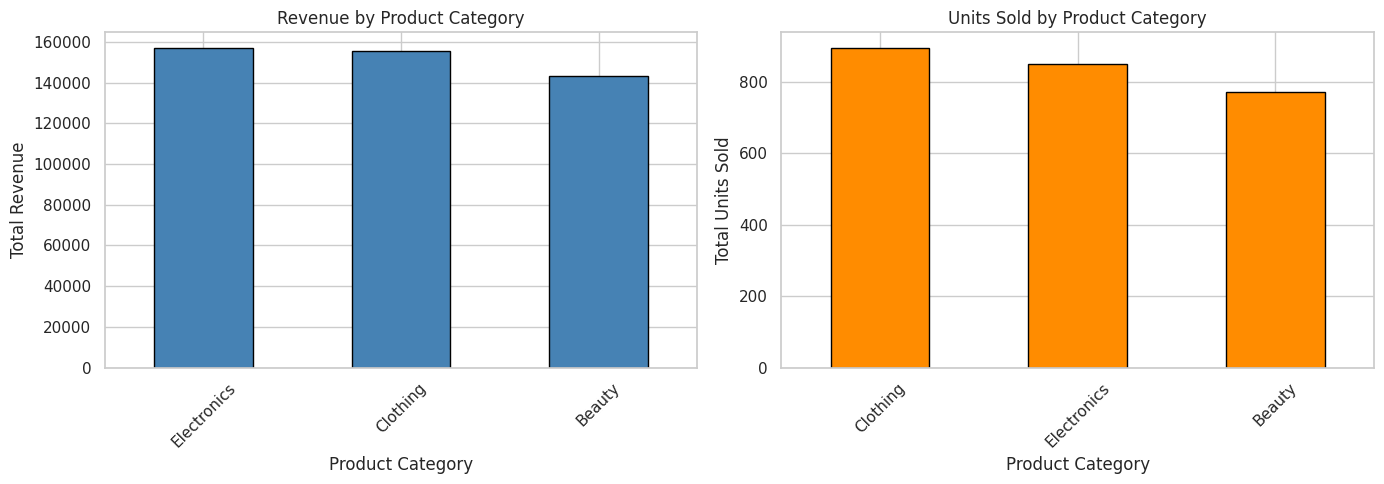

In [6]:
top_products = df.groupby('Product Category')['Total Amount'].sum().sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

top_products.plot(kind='bar', ax=axes[0], color='steelblue', edgecolor='black')
axes[0].set_title('Revenue by Product Category')
axes[0].set_xlabel('Product Category')
axes[0].set_ylabel('Total Revenue')
axes[0].tick_params(axis='x', rotation=45)

df.groupby('Product Category')['Quantity'].sum().sort_values(ascending=False).plot(kind='bar', ax=axes[1], color='darkorange', edgecolor='black')
axes[1].set_title('Units Sold by Product Category')
axes[1].set_xlabel('Product Category')
axes[1].set_ylabel('Total Units Sold')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()


## 🔥 Step 6 — Correlation Heatmap

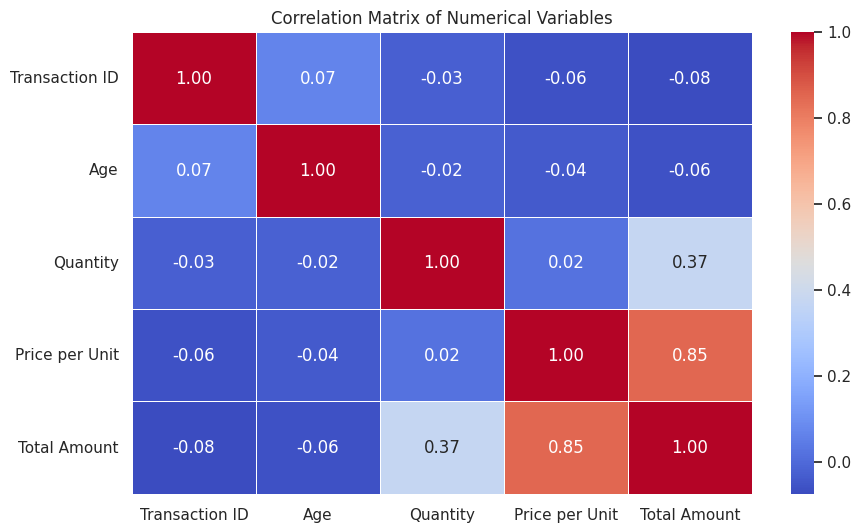

In [7]:
numeric_df = df.select_dtypes(include='number')

plt.figure(figsize=(10, 6))
sns.heatmap(numeric_df.corr(), annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Matrix of Numerical Variables')
plt.show()

## 💡 Step 7 — Additional Insight: Sales Distribution by Age Group & Product Category

/tmp/ipykernel_933/2017457770.py:3: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pivot = df.pivot_table(values='Total Amount', index='Age Group', columns='Product Category', aggfunc='sum')


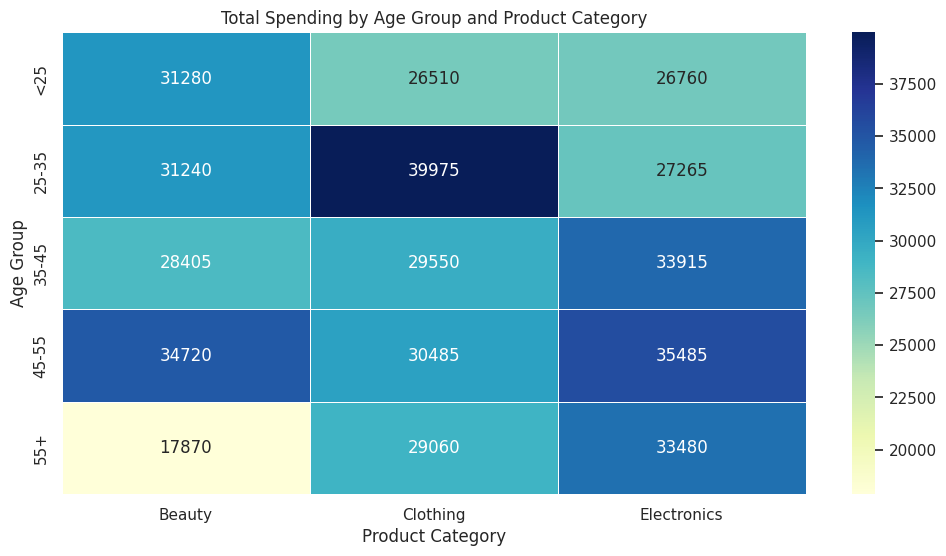

In [8]:
df['Age Group'] = pd.cut(df['Age'], bins=[0, 25, 35, 45, 55, 100], labels=['<25', '25-35', '35-45', '45-55', '55+'])

pivot = df.pivot_table(values='Total Amount', index='Age Group', columns='Product Category', aggfunc='sum')

plt.figure(figsize=(12, 6))
sns.heatmap(pivot, annot=True, fmt='.0f', cmap='YlGnBu', linewidths=0.5)
plt.title('Total Spending by Age Group and Product Category')
plt.xlabel('Product Category')
plt.ylabel('Age Group')
plt.show()

## 📝 Step 8 — Observations & Conclusion

### Key Observations

1. **Monthly & Quarterly Trends** — Sales show noticeable fluctuations across months, with certain quarters performing significantly better, indicating seasonal demand patterns.

2. **Customer Demographics** — The majority of customers fall in the 25-45 age range. Gender distribution is relatively balanced, with slight variation across product categories.

3. **Product Performance** — Certain product categories consistently generate higher revenue and units sold, suggesting strong customer preference for specific segments.

4. **Correlation Insights** — Price per unit and total amount show a strong positive correlation, while age shows minimal correlation with spending behaviour.

5. **Age Group & Product Spending** — Middle-aged customers (35-45) tend to spend the most across most product categories, making them the most valuable segment.

### ✅ Business Recommendations

1. **Target the 35-45 Age Group** — Since this segment spends the most, marketing campaigns and loyalty programs should be focused on retaining and expanding this customer base.

2. **Stock Up Before Peak Quarters** — Sales spikes in certain quarters suggest seasonal demand. Inventory and promotions should be planned in advance to capitalise on these periods.

3. **Push Top Revenue Categories** — Double down on the best-performing product categories through bundling, discounts, and premium offerings to further grow revenue.

## 🏁 End of Analysis
**Analyst:** Param Parag Koli
**Track:** Data Analytics
**Task:** Level 1 — Task 1 · EDA on Retail Sales Data
**Batch:** July 2026
**Internship:** Oasis Infobyte Summer Internship Program